In [1]:
# AUTO-GENERATED from scripts/factors_catalog.py by
# scripts/generate_factor_notebooks.py -- do not edit by hand.
import sys
from pathlib import Path

_repo_root = Path.cwd()
while not (_repo_root / "analysis").is_dir() and _repo_root != _repo_root.parent:
    _repo_root = _repo_root.parent
sys.path.insert(0, str(_repo_root))

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from unravel_client import get_portfolio_returns

from analysis.utils import get_env
from scripts.factors_catalog import load_factors

UNRAVEL_API_KEY = get_env("UNRAVEL_API_KEY")

portfolios = [factor.portfolio_id for factor in load_factors()]

returns_df = pd.DataFrame(
    {
        portfolio: get_portfolio_returns(id=portfolio, api_key=UNRAVEL_API_KEY)
        for portfolio in portfolios
    }
)

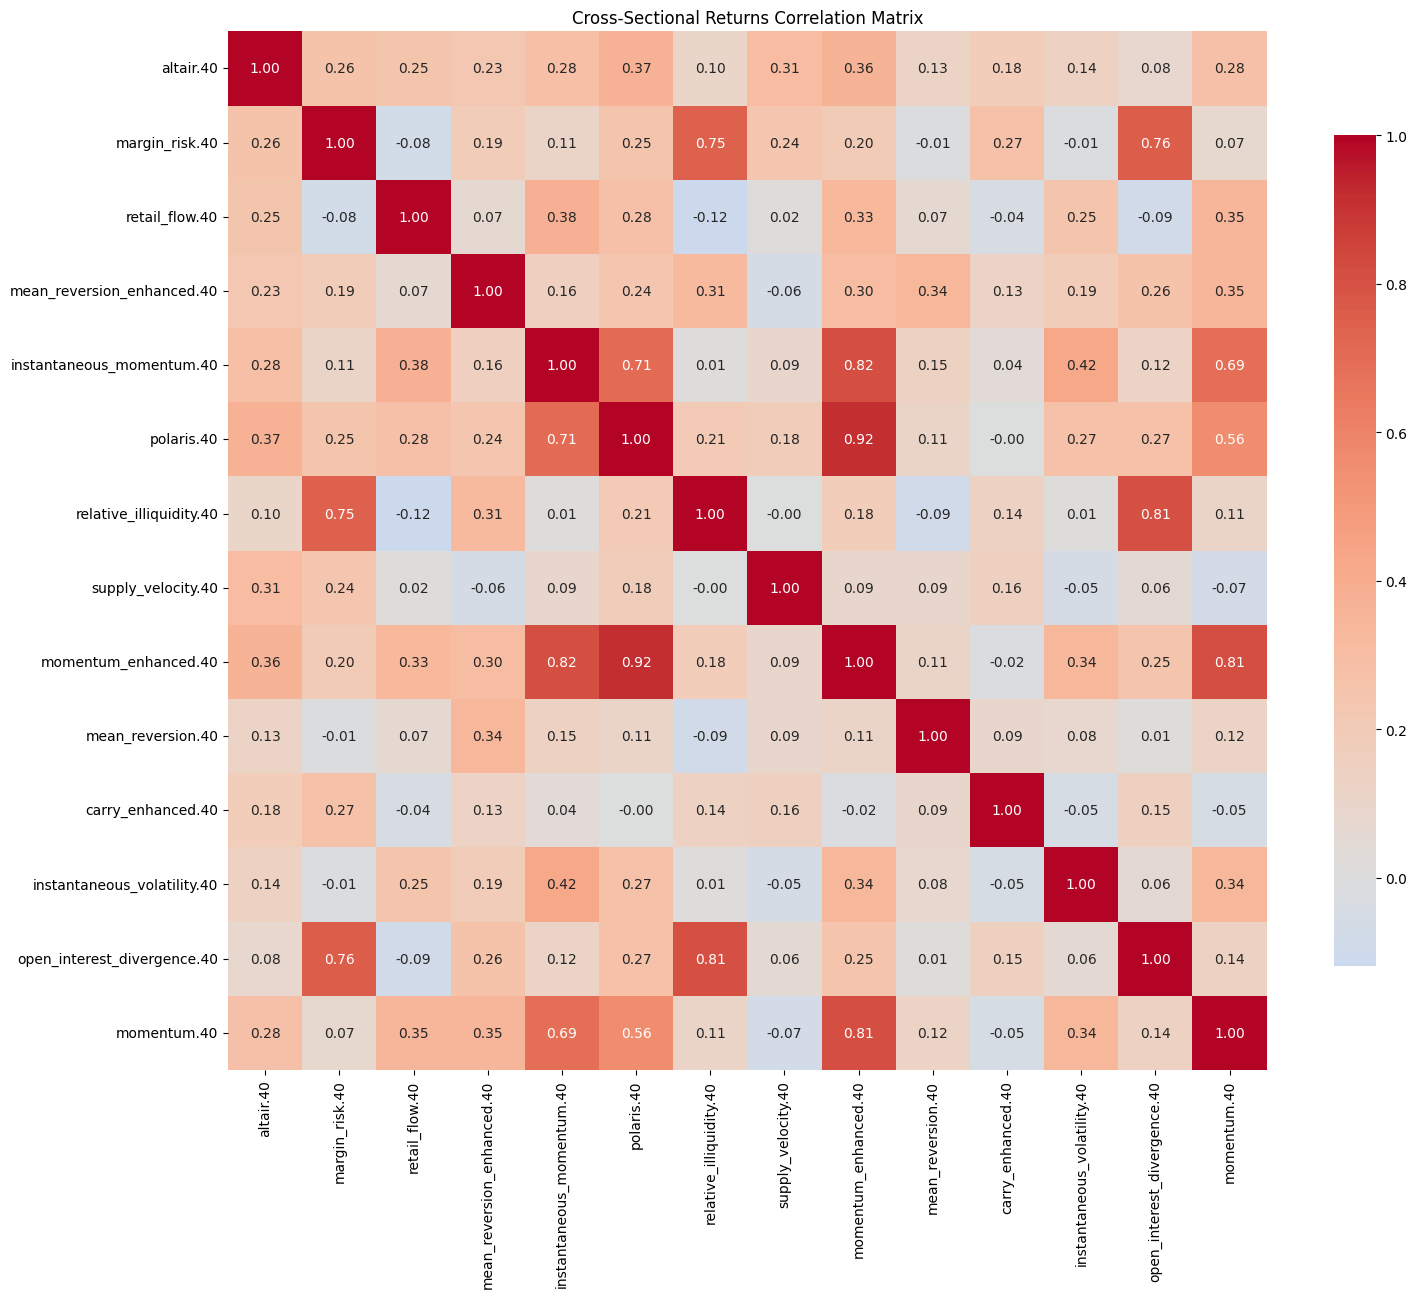

In [2]:

correlation_matrix = returns_df.corr()

plt.figure(figsize=(16, 13))
sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    center=0,
    square=True,
    fmt=".2f",
    cbar_kws={"shrink": 0.8},
)
plt.title("Cross-Sectional Returns Correlation Matrix")
plt.tight_layout()
plt.show()